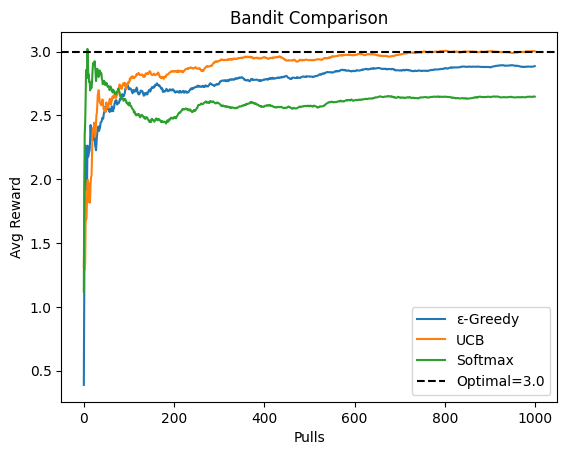

In [1]:
# Experiment 2: Multi-Armed Bandit

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
arms  = [1.5, 2.5, 1.0, 3.0, 2.0]   # true means (arm 3 is best)
T     = 1000

def pull(a): return np.random.normal(arms[a], 1)

def run(strategy):
    Q, N, rewards = np.zeros(5), np.zeros(5), []
    for t in range(1, T+1):
        # --- pick arm based on strategy ---
        if strategy == 'egreedy':
            a = np.random.randint(5) if np.random.random()<0.1 else np.argmax(Q)
        elif strategy == 'ucb':
            a = np.argmax(Q + 2*np.sqrt(np.log(t)/(N+1e-5)))
        else:  # softmax
            e = np.exp(Q/0.5); a = np.random.choice(5, p=e/e.sum())
        r = pull(a)
        N[a] += 1;  Q[a] += (r - Q[a])/N[a]   # incremental average update
        rewards.append(r)
    return np.cumsum(rewards)/np.arange(1,T+1)  # running average

plt.plot(run('egreedy'), label='ε-Greedy')
plt.plot(run('ucb'),     label='UCB')
plt.plot(run('softmax'), label='Softmax')
plt.axhline(3.0, ls='--', color='k', label='Optimal=3.0')
plt.xlabel('Pulls'); plt.ylabel('Avg Reward')
plt.title('Bandit Comparison'); plt.legend(); plt.show()